# Tugas Mandiri -- REAL MADRID HAIKAL PUTRA : 51423260
---
Segmentasi Pelanggan menggunakan Metode **K-Means Clustering**

Dataset: [Customers Transactions - Kaggle](https://www.kaggle.com/datasets/fares279/customers-transactions)

## Kerangka Kerja: CRISP-DM

Notebook ini disusun mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, yaitu metodologi standar dalam proyek data mining/machine learning yang terdiri dari 5 fase berikut:

| Fase | Nama Fase | Ringkasan Isi pada Notebook Ini |
|---|---|---|
| 1 | **Business Understanding** | Menentukan tujuan, metode, dan rumusan masalah clustering |
| 2 | **Data Understanding** | Memuat dataset, eksplorasi awal, cek missing value & statistik deskriptif |
| 3 | **Data Preparation** | Seleksi fitur dan standardisasi data |
| 4 | **Modeling** | Penentuan jumlah cluster optimal (Elbow & Silhouette) dan training model K-Means |
| 5 | **Evaluation** | Analisis karakteristik cluster dan evaluasi Silhouette Score |


# 🔵 FASE 1 — BUSINESS UNDERSTANDING
---
Memahami tujuan bisnis, metode, dan rumusan masalah sebelum masuk ke tahap teknis.

## 1. Tujuan

Tujuan dari proses clustering pada dataset *Customers Transactions* adalah untuk melakukan segmentasi pelanggan berdasarkan karakteristik dan perilaku transaksi mereka. Segmentasi dilakukan dengan mengelompokkan pelanggan yang memiliki karakteristik serupa ke dalam kelompok (cluster) yang sama.

Dengan adanya proses clustering, diharapkan dapat diketahui pola dan karakteristik dari setiap kelompok pelanggan berdasarkan pendapatan, tingkat pengeluaran, dan jumlah pembelian.

## 2. Metode yang Digunakan

Metode clustering yang digunakan adalah **K-Means Clustering**. K-Means merupakan metode *unsupervised learning* yang digunakan untuk mengelompokkan data ke dalam beberapa cluster berdasarkan tingkat kemiripan karakteristik antar data.

Pada proses ini, pelanggan akan dikelompokkan berdasarkan tiga fitur numerik, yaitu:
* **Annual Income** – menunjukkan pendapatan tahunan pelanggan.
* **Spending Score** – menunjukkan tingkat atau pola pengeluaran pelanggan.
* **Number of Purchases** – menunjukkan jumlah pembelian yang dilakukan pelanggan.

Sebelum dilakukan proses K-Means, data numerik akan melalui proses standardisasi agar setiap fitur memiliki skala yang sebanding dan tidak ada fitur yang mendominasi proses clustering hanya karena memiliki nilai yang lebih besar.

## 3. Hal yang Dicari

Melalui proses K-Means Clustering, hal yang ingin diketahui adalah:
1. Jumlah cluster yang optimal untuk mengelompokkan pelanggan.
2. Karakteristik masing-masing cluster berdasarkan Annual Income, Spending Score, dan Number of Purchases.
3. Pola perilaku pelanggan yang terdapat pada masing-masing cluster.
4. Perbedaan karakteristik antar-cluster yang terbentuk.
5. Seberapa baik hasil pengelompokan yang diperoleh dari metode K-Means.

Untuk menentukan jumlah cluster yang optimal, digunakan **Elbow Method** dan **Silhouette Score**. Hasil dari kedua metode tersebut kemudian digunakan sebagai pertimbangan dalam menentukan jumlah cluster yang akan digunakan pada proses K-Means.

# 🟢 FASE 2 — DATA UNDERSTANDING
---
Memuat dataset dan melakukan eksplorasi awal untuk memahami struktur, kualitas, dan karakteristik data sebelum diproses lebih lanjut.

---
## 5. Import Library

In [ ]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')

## 6. Memuat Dataset

In [ ]:
# Memuat dataset Customers Transactions
# Dataset diunduh dari: https://www.kaggle.com/datasets/fares279/customers-transactions
df = pd.read_csv('Customer_Transactions.csv')

df.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21


In [ ]:
# Melihat informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   country                   10000 non-null  object 
 4   annual_income             10000 non-null  int64  
 5   spending_score            10000 non-null  int64  
 6   num_purchases             10000 non-null  int64  
 7   avg_purchase_value        10000 non-null  float64
 8   membership_years          10000 non-null  int64  
 9   website_visits_per_month  10000 non-null  int64  
 10  cart_abandon_rate         10000 non-null  float64
 11  churned                   10000 non-null  int64  
 12  feedback_text             10000 non-null  object 
 13  last_purchase_date        10000 non-null  object 
dtypes: floa

In [ ]:
# Mengecek missing value pada dataset
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
country,0
annual_income,0
spending_score,0
num_purchases,0
avg_purchase_value,0
membership_years,0
website_visits_per_month,0


In [ ]:
# Statistik deskriptif dataset
df.describe()

,customer_id,age,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,44.045800,86067.676100,50.924200,22.576000,47.447480,6.340500,15.578100,0.501216,0.109000
std,2886.89568,15.404669,38986.787991,28.753395,10.163639,11.205902,4.680657,8.655322,0.286836,0.311655
min,1.00000,18.000000,20028.000000,1.000000,1.000000,16.750000,0.000000,1.000000,0.000000,0.000000
25%,2500.75000,31.000000,55345.500000,26.000000,14.000000,39.500000,2.000000,8.000000,0.250000,0.000000
50%,5000.50000,44.000000,78339.500000,51.000000,22.000000,46.990000,6.000000,16.000000,0.510000,0.000000
75%,7500.25000,57.000000,115570.500000,75.000000,31.000000,55.080000,10.000000,23.000000,0.750000,0.000000
max,10000.00000,70.000000,179960.000000,100.000000,49.000000,83.270000,15.000000,30.000000,1.000000,1.000000


Berdasarkan hasil di atas, dataset tidak memiliki *missing value* sehingga dapat langsung digunakan pada tahap selanjutnya tanpa proses *imputation*.

# 🟡 FASE 3 — DATA PREPARATION
---
Menyiapkan data agar siap digunakan pada tahap pemodelan, meliputi seleksi fitur relevan dan standardisasi skala data.

## 7. Seleksi Fitur untuk Clustering

In [ ]:
# Memilih tiga fitur numerik yang digunakan untuk proses clustering
features = ['annual_income', 'spending_score', 'num_purchases']
X = df[features]

X.head()

,annual_income,spending_score,num_purchases
0,85886,14,18
1,41041,4,10
2,143869,59,39
3,87261,45,34
4,110678,40,38


## 8. Standardisasi Data

Standardisasi dilakukan agar setiap fitur memiliki skala yang sebanding, sehingga tidak ada fitur yang mendominasi proses clustering hanya karena memiliki rentang nilai yang lebih besar.

In [ ]:
# Melakukan standardisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.00466017, -1.28423256, -0.45025496],
       [-1.15497916, -1.63203497, -1.23741399],
       [ 1.48266162,  0.28087827,  1.61603748],
       [ 0.03060995, -0.2060451 ,  1.12406309],
       [ 0.63127936, -0.37994631,  1.5176426 ]])

# 🟠 FASE 4 — MODELING
---
Menentukan jumlah cluster optimal (Elbow Method & Silhouette Score), melatih model K-Means, lalu memvisualisasikan hasil pengelompokan.

## 9. Menentukan Jumlah Cluster Optimal

#### Elbow Method

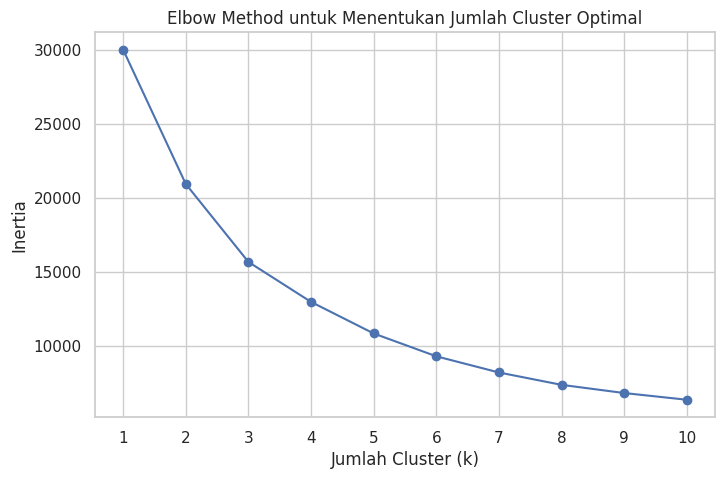

In [ ]:
# Menghitung nilai inertia untuk k = 1 sampai 10 (Elbow Method)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal')
plt.xticks(list(K_range))
plt.show()

#### Silhouette Score

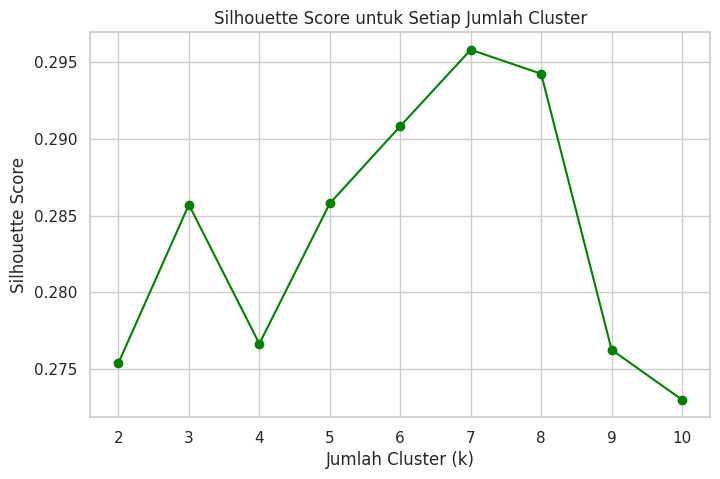

In [ ]:
# Menghitung Silhouette Score untuk k = 2 sampai 10
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range_sil), silhouette_scores, marker='o', color='green')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Setiap Jumlah Cluster')
plt.xticks(list(K_range_sil))
plt.show()

In [ ]:
# Menampilkan nilai Silhouette Score pada setiap k
for k, score in zip(K_range_sil, silhouette_scores):
    print(f'k = {k} -> Silhouette Score = {score:.4f}')

k = 2 -> Silhouette Score = 0.2754
k = 3 -> Silhouette Score = 0.2857
k = 4 -> Silhouette Score = 0.2767
k = 5 -> Silhouette Score = 0.2858
k = 6 -> Silhouette Score = 0.2908
k = 7 -> Silhouette Score = 0.2958
k = 8 -> Silhouette Score = 0.2942
k = 9 -> Silhouette Score = 0.2763
k = 10 -> Silhouette Score = 0.2730


**Analisis:** Grafik Elbow Method tidak menunjukkan siku (*elbow*) yang terlalu tajam, tetapi penurunan inertia mulai melandai di sekitar k = 4 sampai k = 7. Hal ini sejalan dengan hasil Silhouette Score, di mana skor tertinggi diperoleh pada **k = 7 (0.2958)**, namun perbedaannya sangat tipis dibandingkan k = 4 hingga k = 8 (berkisar 0.27–0.30). Karena seluruh nilai Silhouette Score berada pada rentang yang relatif rendah dan cenderung datar, dapat disimpulkan bahwa struktur cluster pada dataset ini tidak terpisah secara sangat tegas.

Dengan mempertimbangkan kemudahan interpretasi bisnis (segmentasi pelanggan biasanya lebih mudah dikomunikasikan dalam jumlah kelompok yang tidak terlalu banyak) serta nilai Silhouette Score k = 4 (0.2767) yang tidak jauh berbeda dari nilai tertinggi, maka jumlah cluster yang dipilih untuk proses selanjutnya adalah **k = 4**.

## 10. Melatih Model K-Means

In [ ]:
# Melatih model K-Means dengan jumlah cluster optimal
k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

df.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date,Cluster
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22,2
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17,2
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01,1
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17,0
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21,1


In [ ]:
# Menghitung Silhouette Score dari model final
final_score = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score (k={k_optimal}) : {final_score:.4f}')

Silhouette Score (k=4) : 0.2767


In [ ]:
# Jumlah pelanggan pada masing-masing cluster
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,2174
1,2363
2,3054
3,2409


## 11. Visualisasi Hasil Clustering

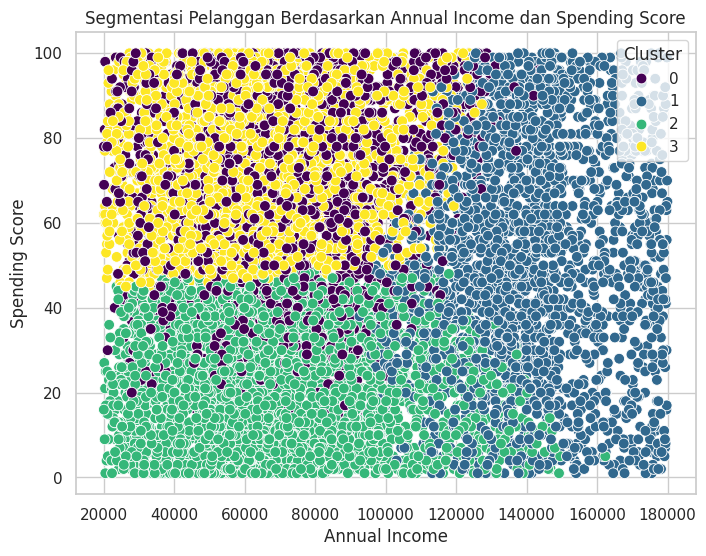

In [ ]:
# Visualisasi hasil clustering berdasarkan Annual Income dan Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='annual_income',
    y='spending_score',
    hue='Cluster',
    palette='viridis',
    s=60
)
plt.title('Segmentasi Pelanggan Berdasarkan Annual Income dan Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

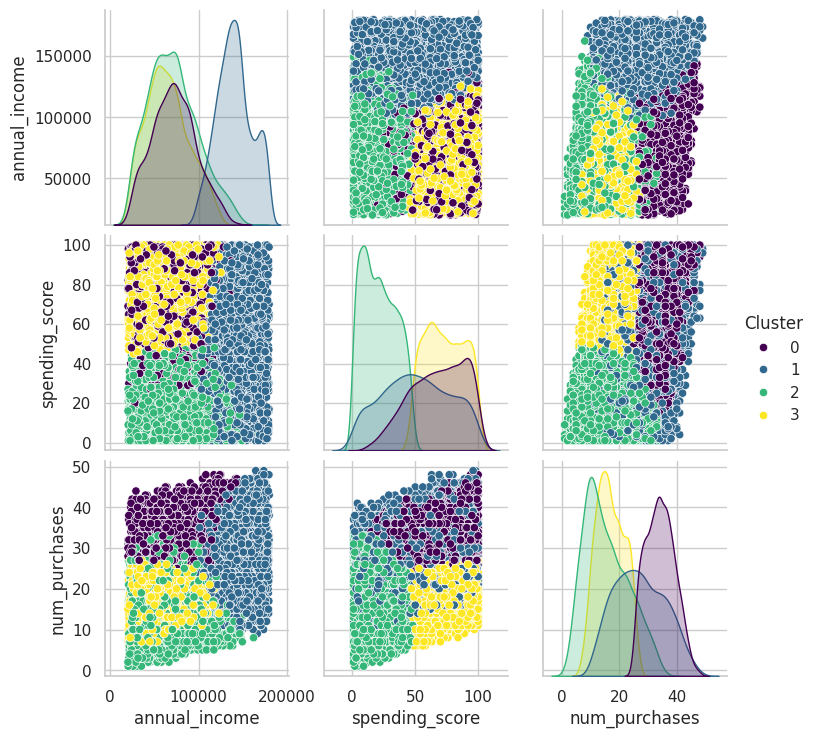

In [ ]:
# Visualisasi hasil clustering pada ketiga fitur menggunakan pairplot
sns.pairplot(
    df,
    vars=features,
    hue='Cluster',
    palette='viridis'
)
plt.show()

# 🔴 FASE 5 — EVALUATION
---
Mengevaluasi kualitas hasil clustering (Silhouette Score) dan menganalisis karakteristik masing-masing cluster untuk memastikan hasil model dapat diinterpretasikan secara bisnis.

## 12. Karakteristik Masing-Masing Cluster

In [ ]:
# Menghitung rata-rata nilai fitur pada setiap cluster
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary

,annual_income,spending_score,num_purchases
Cluster,,,
0,71977.55,67.63,34.14
1,140371.16,50.91,27.04
2,71032.50,21.33,15.43
3,64577.53,73.39,16.82


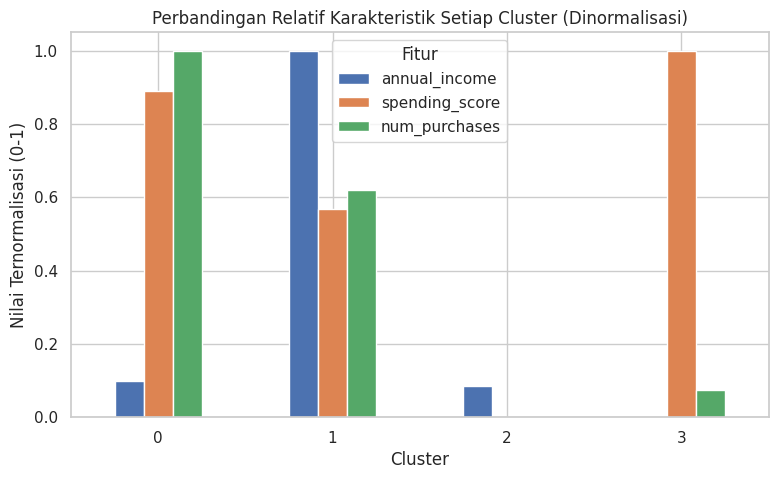

In [ ]:
# Visualisasi karakteristik rata-rata tiap cluster
cluster_summary_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())

cluster_summary_norm.plot(kind='bar', figsize=(9, 5))
plt.title('Perbandingan Relatif Karakteristik Setiap Cluster (Dinormalisasi)')
plt.xlabel('Cluster')
plt.ylabel('Nilai Ternormalisasi (0-1)')
plt.xticks(rotation=0)
plt.legend(title='Fitur')
plt.show()

**Analisis Karakteristik Cluster:**

Berdasarkan tabel `cluster_summary`, keempat cluster menunjukkan karakteristik pelanggan yang berbeda:

| Cluster | Annual Income | Spending Score | Num Purchases | Jumlah Pelanggan |
|---|---|---|---|---|
| 0 | 71.977,55 (sedang) | 67,63 (tinggi) | 34,14 (**tertinggi**) | 2.174 |
| 1 | 140.371,16 (**tertinggi**) | 50,91 (sedang) | 27,04 (sedang-tinggi) | 2.363 |
| 2 | 71.032,50 (sedang) | 21,33 (**terendah**) | 15,43 (**terendah**) | 3.054 |
| 3 | 64.577,53 (**terendah**) | 73,39 (**tertinggi**) | 16,82 (rendah) | 2.409 |

* **Cluster 0 – Pelanggan Aktif (Annual Income sedang, Spending Score tinggi, jumlah pembelian tertinggi).** Kelompok ini paling sering bertransaksi dan cukup royal berbelanja meski pendapatannya tidak paling tinggi. Cluster ini paling potensial untuk program loyalitas karena frekuensi transaksinya paling banyak.
* **Cluster 1 – Pelanggan Berpendapatan Tinggi (Annual Income tertinggi, Spending Score & jumlah pembelian sedang).** Pelanggan pada cluster ini memiliki daya beli paling besar, namun belanjanya belum semaksimal Cluster 0. Cluster ini berpeluang ditingkatkan nilainya (*upselling*) melalui promosi yang lebih personal.
* **Cluster 2 – Pelanggan Kurang Aktif (Spending Score dan jumlah pembelian paling rendah, Annual Income sedang).** Meskipun pendapatannya tidak rendah, kelompok ini paling jarang berbelanja dan menghabiskan skor pengeluaran paling kecil. Cluster ini merupakan yang terbesar (3.054 pelanggan) sehingga penting menjadi target strategi re-engagement.
* **Cluster 3 – Pelanggan Royal Berpendapatan Rendah (Annual Income terendah, Spending Score tertinggi, jumlah pembelian rendah).** Pelanggan pada cluster ini memiliki pendapatan paling terbatas, tetapi ketika berbelanja cenderung menghabiskan proporsi pengeluaran yang besar meski frekuensi pembeliannya tidak tinggi — mengindikasikan pembelian bernilai besar namun jarang.


## 13. Evaluasi Hasil Clustering

**Analisis Evaluasi:** Model final dengan k = 4 menghasilkan Silhouette Score sebesar **0.2767**. Nilai ini berada pada rentang 0 sampai 1, dan secara umum nilai di bawah 0.3 mengindikasikan struktur cluster yang **cukup lemah hingga sedang** — artinya antar cluster masih terdapat sedikit tumpang tindih (*overlap*) dan batas antar kelompok tidak terlalu tegas.

Hal ini wajar terjadi karena fitur yang digunakan (Annual Income, Spending Score, Number of Purchases) berasal dari data transaksi yang bersifat kontinu dan tidak memiliki pemisahan alami yang tajam antar kelompok pelanggan. Meskipun demikian, hasil clustering tetap dapat digunakan sebagai dasar segmentasi karena perbedaan rata-rata karakteristik antar cluster (lihat tabel `cluster_summary`) masih cukup jelas terlihat dan dapat diinterpretasikan secara bisnis.